In [1]:
from pathlib import Path
import yaml, numpy as np, pandas as pd, torch
import umap
import joblib
import matplotlib.pyplot as plt

from clearit.config import MODELS_DIR, DATASETS_DIR, OUTPUTS_DIR
from clearit.inference.utils import get_embeddings

# -------------------------------------------------------------------
# 1. Locate UMAP/PCA bundle and encoder
# -------------------------------------------------------------------

umap_dir = OUTPUTS_DIR / "umap" / "TNBC1-MxIF8" / "TME-A_ML6" / "E0030"

# load metadata
meta_path = umap_dir / "metadata.yaml"
meta = yaml.safe_load(meta_path.read_text())

encoder_id = meta["encoder_id"]
enc_dir = MODELS_DIR / "encoders" / encoder_id
enc_cfg = yaml.safe_load((enc_dir / "conf_enc.yaml").read_text())

# load trained PCA and UMAP models
pca_model_path = umap_dir / "pca_model.joblib"
umap_model_path = umap_dir / "umap_model.joblib"

pca = joblib.load(pca_model_path)
umap_model = joblib.load(umap_model_path)

print("Loaded:")
print("  encoder      :", encoder_id)
print("  PCA model    :", pca_model_path)
print("  UMAP model   :", umap_model_path)
print("  metadata from:", meta_path)


Loaded:
  encoder      : E0030
  PCA model    : /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/pca_model.joblib
  UMAP model   : /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/umap_model.joblib
  metadata from: /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/metadata.yaml


In [2]:
# -------------------------------------------------------------------
# 2. Specify and build the test set (independent of UMAP training set)
# -------------------------------------------------------------------

dataset_name = "TNBC1-MxIF8"
annotation_name = "inForm_MC7"
index_rel_path = "indices/test/test_full01.npz"

labels_path = DATASETS_DIR / dataset_name / annotation_name / "labels.csv"
df_labels = pd.read_csv(labels_path)

npz_path = DATASETS_DIR / dataset_name / annotation_name / index_rel_path
arr = np.load(npz_path)
files = arr.files

test_indices = arr[files[0]]
df_test = df_labels.iloc[test_indices].reset_index(drop=True)

# make sure we have one row per cell
key_cols = ["fname", "cell_x", "cell_y"]
df_test = df_test.drop_duplicates(subset=key_cols).reset_index(drop=True)

print("Test dataframe shape:", df_test.shape)
print("Columns:", df_test.columns.tolist())


Test dataframe shape: (572648, 6)
Columns: ['cell_id', 'cell_area', 'cell_x', 'cell_y', 'label', 'fname']


In [3]:
# -------------------------------------------------------------------
# 3. Pass encoder image size (if present) via attrs so get_embeddings
#    uses the correct crop size
# -------------------------------------------------------------------
df_test = df_test.sample(50000,random_state=42)
if "img_size" in enc_cfg:
    df_test.attrs["img_size"] = int(enc_cfg["img_size"])


In [4]:
# -------------------------------------------------------------------
# 4. Extract multiplex features for the test set
# -------------------------------------------------------------------

X_test = get_embeddings(
    df_test,
    dataset_name=dataset_name,
    annotation_name=annotation_name,
    encoder_id=encoder_id,
    batch_size=128,
    num_workers=20,
    proj_layers=0,
).cpu().numpy()

print("Test features shape:", X_test.shape)  # [N_test, D]


Loaded & padded 248 images in 135.7s (1.8 f/s)
Extracted 50000 crops in 24.7s (2022.3 crops/s)
Test features shape: (50000, 4096)


In [5]:
# -------------------------------------------------------------------
# 5. Apply PCA, then UMAP, to test features
# -------------------------------------------------------------------

X_test_pca = pca.transform(X_test)
print("PCA-transformed test shape:", X_test_pca.shape)

emb_test = umap_model.transform(X_test_pca)
print("UMAP test embedding shape:", emb_test.shape)


PCA-transformed test shape: (50000, 64)


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP test embedding shape: (50000, 2)


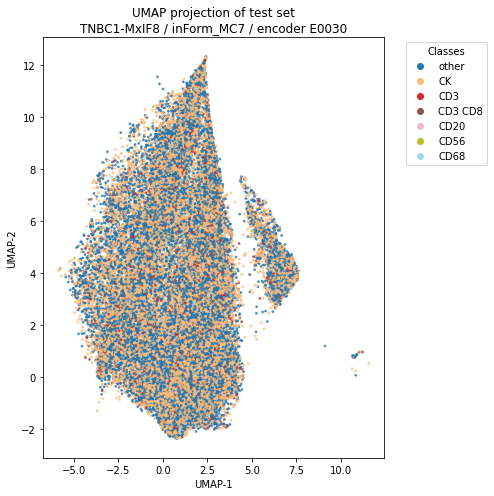

In [7]:
# -------------------------------------------------------------------
# 6. Plot: UMAP (test) colored by label
# -------------------------------------------------------------------

# Example: specify class_strings explicitly (index = label integer)
# Replace this with the actual class names for inForm_MC7
class_strings = [
    "other",
    "CK",
    "CD3",
    "CD3 CD8",
    "CD20",
    "CD56",
    "CD68",
]

if "label" not in df_test.columns:
    raise KeyError("Expected an integer 'label' column in df_test.")

labels = df_test["label"].astype(int).to_numpy()

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    emb_test[:, 0],
    emb_test[:, 1],
    c=labels,
    cmap="tab20",
    s=3,
    alpha=0.7,
)

plt.title(f"UMAP projection of test set\n{dataset_name} / {annotation_name} / encoder {encoder_id}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# Build a legend using class_strings
unique_labels = np.unique(labels)
handles = []
texts = []
for lab in unique_labels:
    idx = labels == lab
    if not np.any(idx):
        continue
    # pick a representative point color from the colormap
    color = scatter.cmap(scatter.norm(lab))
    handles.append(plt.Line2D([], [], marker="o", linestyle="", color=color, markersize=6))
    name = class_strings[lab] if lab < len(class_strings) else f"class {lab}"
    texts.append(name)

plt.legend(handles, texts, title="Classes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
